# 🎓 Student Habits & Academic Performance — Predictive Modelling
---
**Objective:** Build an interpretable, well-validated regression model that predicts a student's exam score from lifestyle and demographic features, and identify which habits matter most.

**Pipeline overview:**
1. Data Loading & Wrangling  
2. Exploratory Data Analysis (EDA)  
3. Pre-processing  
4. Model Comparison   
5. Hyperparameter Tuning  
6. Final Model Evaluation & Diagnostics  
7. Feature Importance  
8. Interactive Prediction Widget

In [68]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from scipy import stats
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
warnings.filterwarnings("ignore")

## Data Loading & Wrangling

In [2]:
def wrangle(filepath):
    df=pd.read_csv(filepath)
    df=df.drop(columns=["student_id"])
    return df

In [3]:
df=wrangle("C:/Users/musyo/Downloads/Datasets-20240315/student_habits_performance.csv")
print("df shape:",df.shape)
df.head()

df shape: (1000, 15)


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [6]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


## Exploratory Data Analysis (EDA)

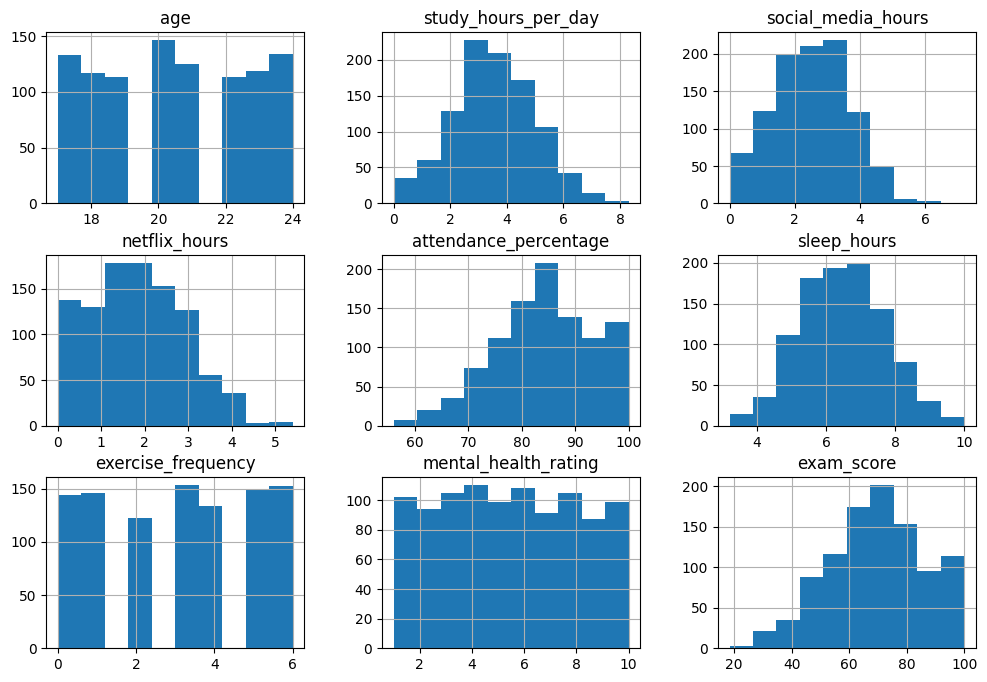

In [12]:
df.hist(figsize=(12,8));

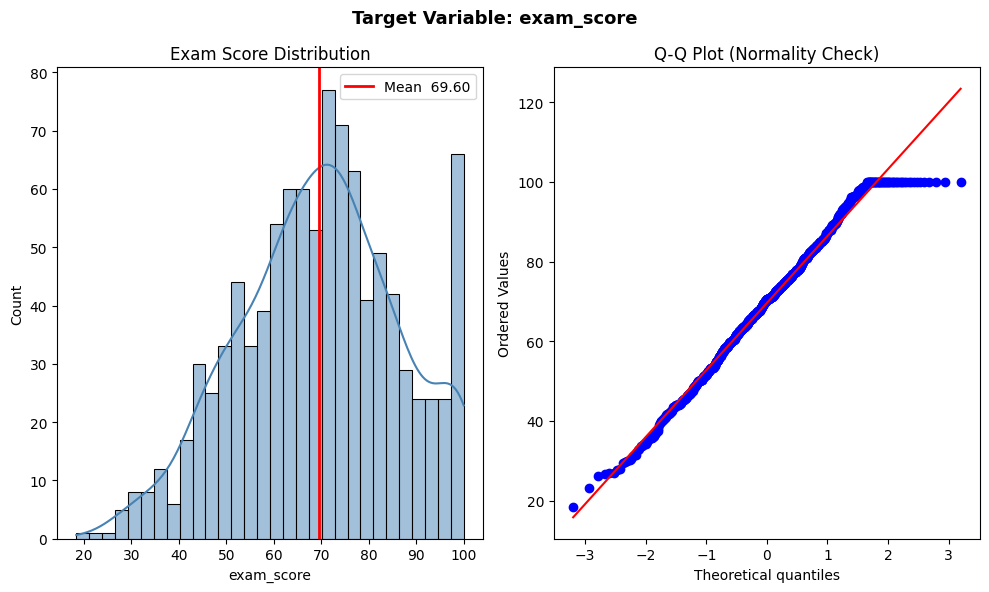

Skewness: -0.1564  |  Kurtosis: -0.4199


In [96]:
target="exam_score"

fig, axes = plt.subplots(1, 2, figsize=(10,6))

# Histogram + KDE
sns.histplot(df[target], kde=True, ax=axes[0], color="steelblue", bins=30)
axes[0].axvline(df[target].mean(),color="red",lw=2, linestyle="-", label=f"Mean  {df[target].mean():.2f}")
axes[0].set_title("Exam Score Distribution")
axes[0].legend()

# Q-Q plot
stats.probplot(df[target], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")

plt.suptitle("Target Variable: exam_score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

sk = df[target].skew()
ku = df[target].kurtosis()
print(f"Skewness: {sk:.4f}  |  Kurtosis: {ku:.4f}")


## Numerical Feature Distributions

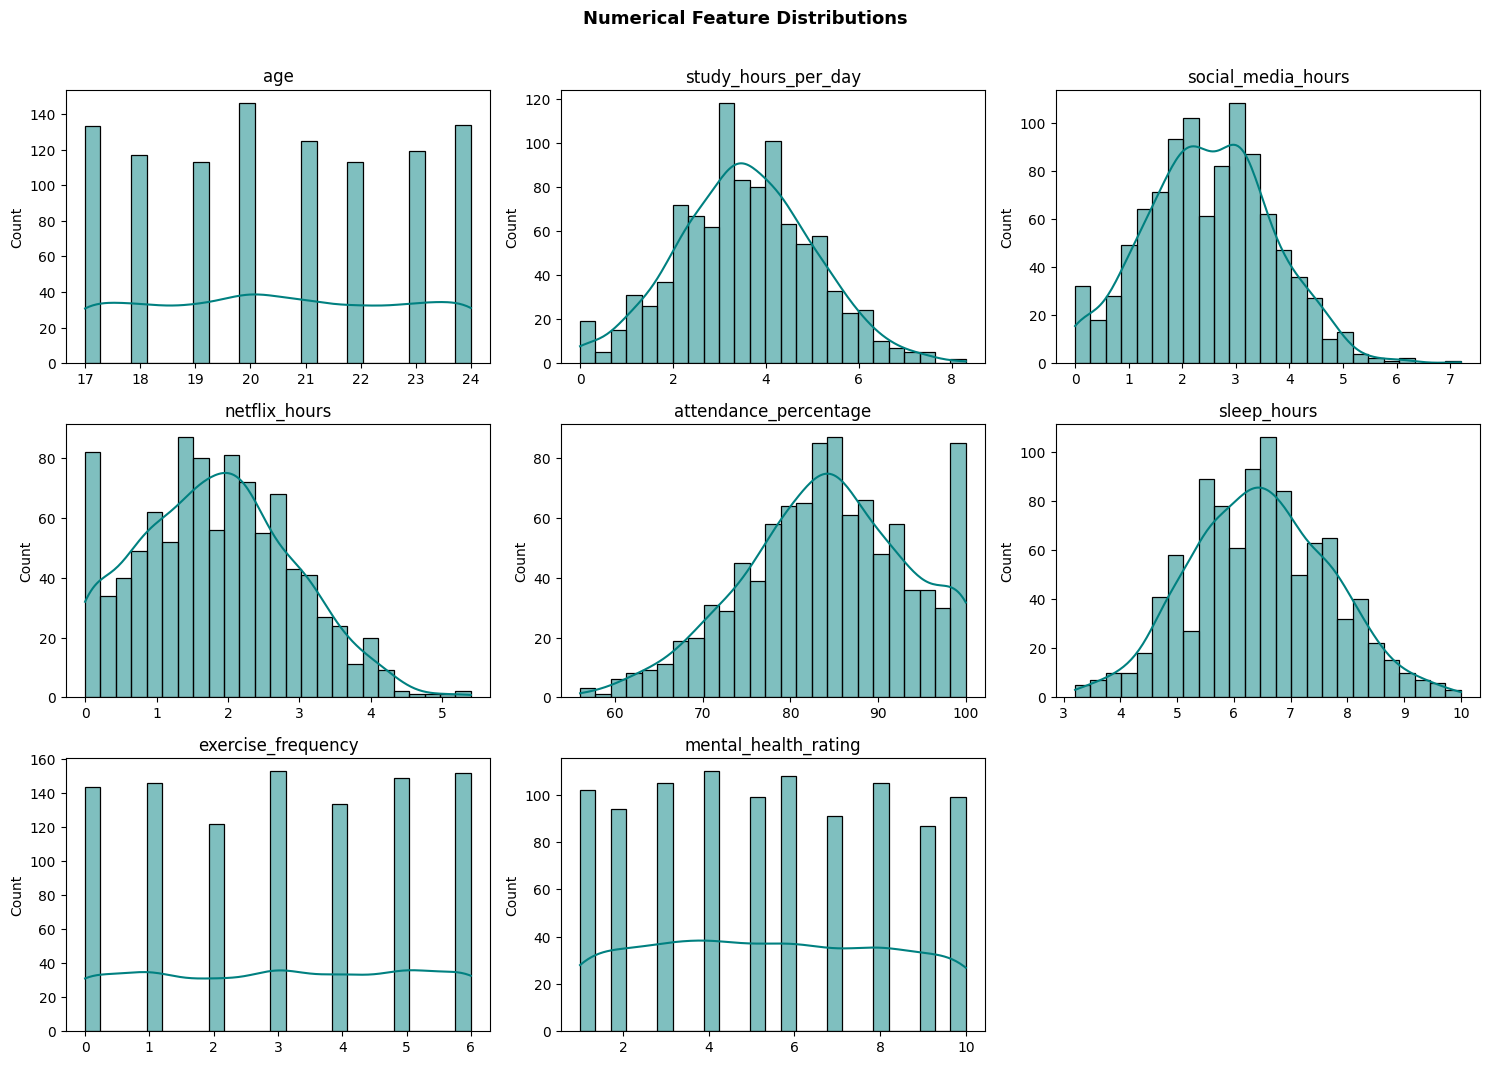

In [101]:
num_cols = df.select_dtypes("number").columns.drop(target).tolist()
n= len(num_cols)
ncols = 3
nrows=-(-n // ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=25, color="teal")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Categorical Features VS Exam score

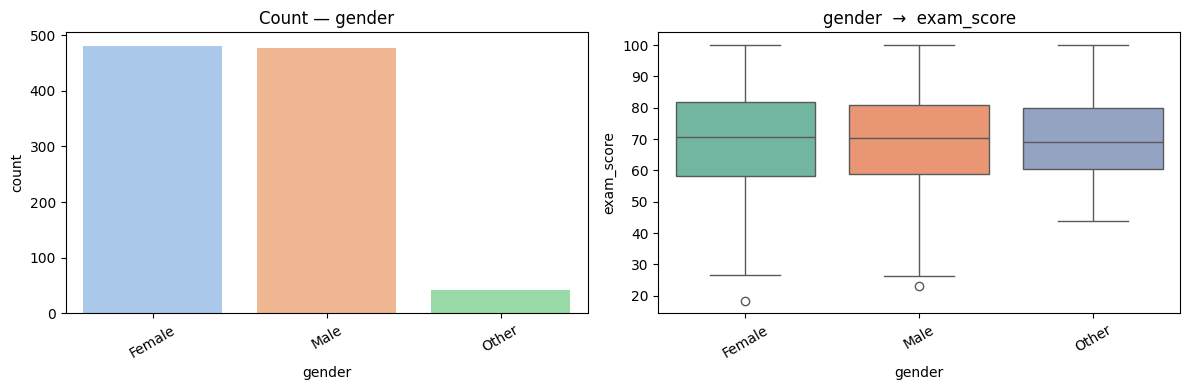

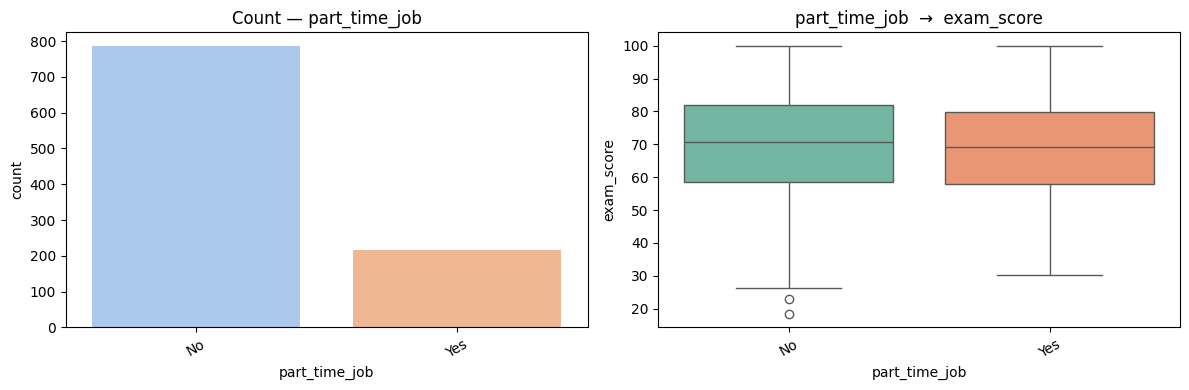

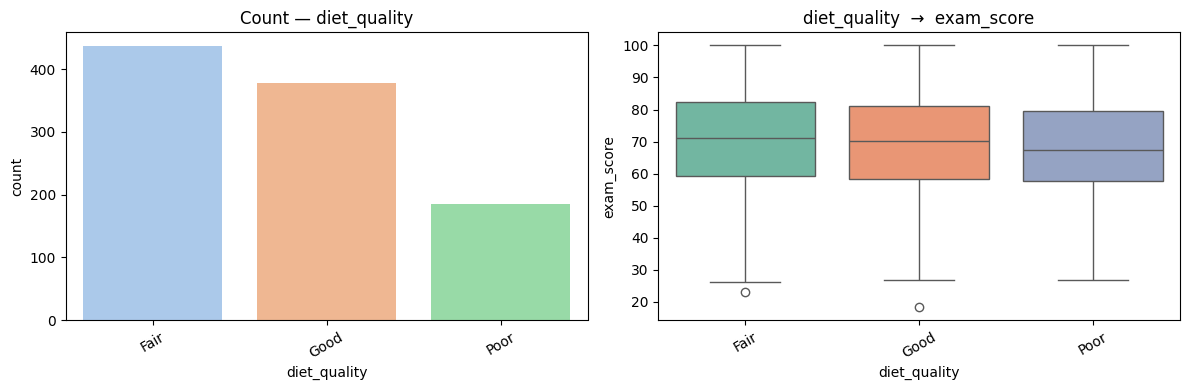

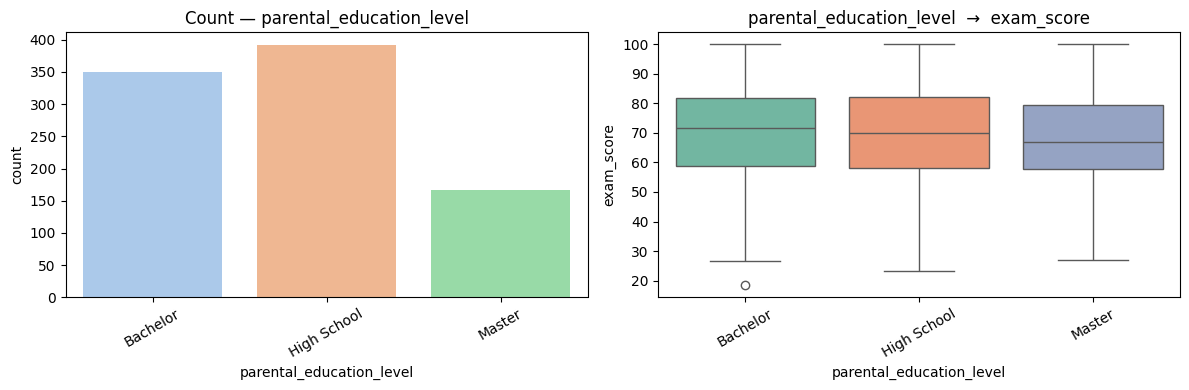

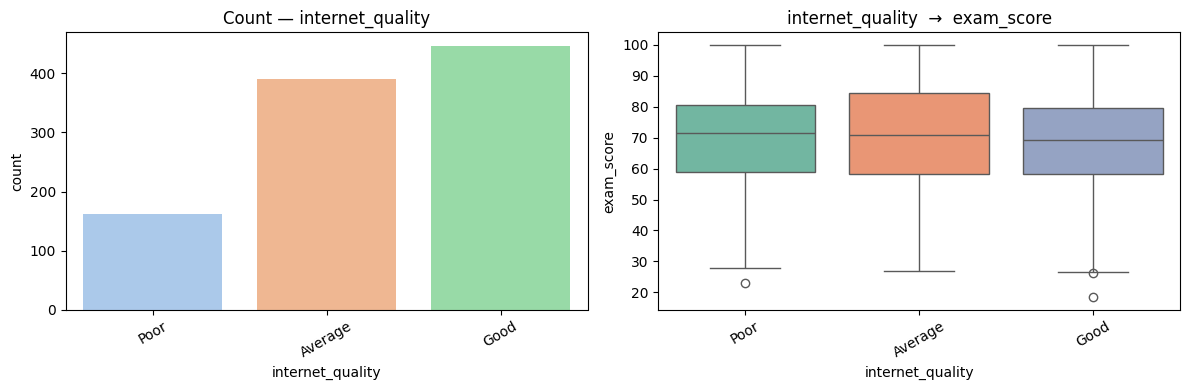

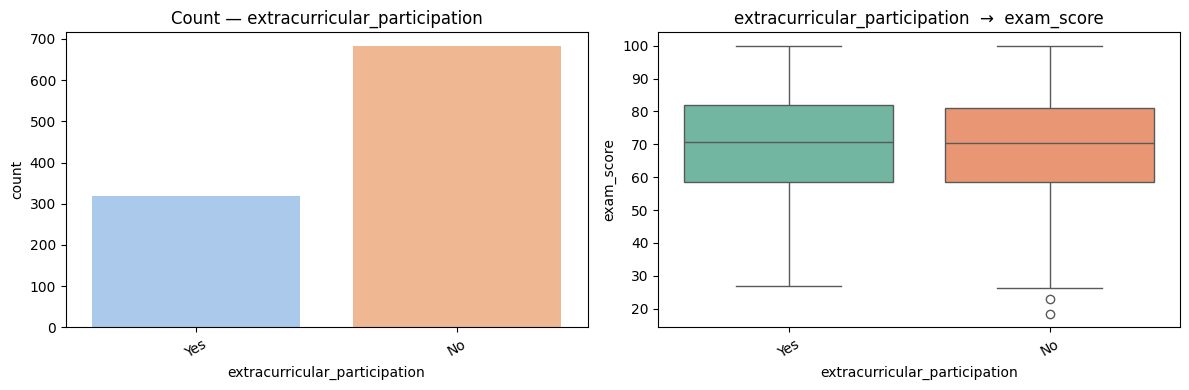

In [102]:
cat_cols = df.select_dtypes("object").columns.tolist()

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    order = df.groupby(col)[target].median().sort_values(ascending=False).index

    # Count plot
    sns.countplot(data=df, x=col, order=order, ax=axes[0], palette="pastel")
    axes[0].set_title(f"Count — {col}")
    axes[0].tick_params(axis="x", rotation=30)

    # Boxplot vs target
    sns.boxplot(data=df, x=col, y=target, order=order, ax=axes[1], palette="Set2")
    axes[1].set_title(f"{col}  →  {target}")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## Exam Score Distributrion

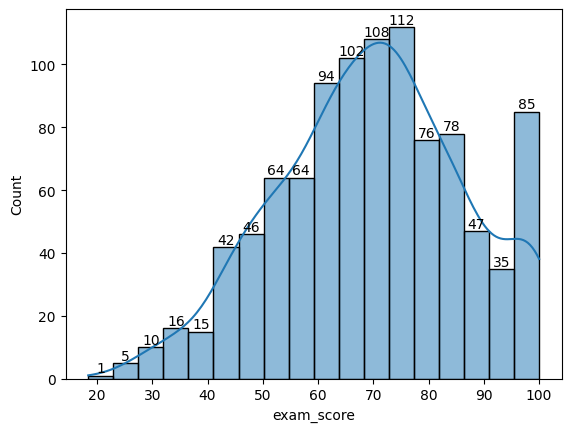

In [128]:
ax=sns.histplot(df["exam_score"],kde=True)
for container in ax.containers:
    ax.bar_label(container,fmt="%.f");

## Checking for Null values

In [21]:
df.isnull().sum().sort_values(ascending=False).head()

parental_education_level    91
gender                       0
age                          0
social_media_hours           0
netflix_hours                0
dtype: int64

In [130]:
df.select_dtypes("object").nunique()

gender                           3
part_time_job                    2
diet_quality                     3
parental_education_level         3
internet_quality                 3
extracurricular_participation    2
dtype: int64

## Feature Correlations with Target

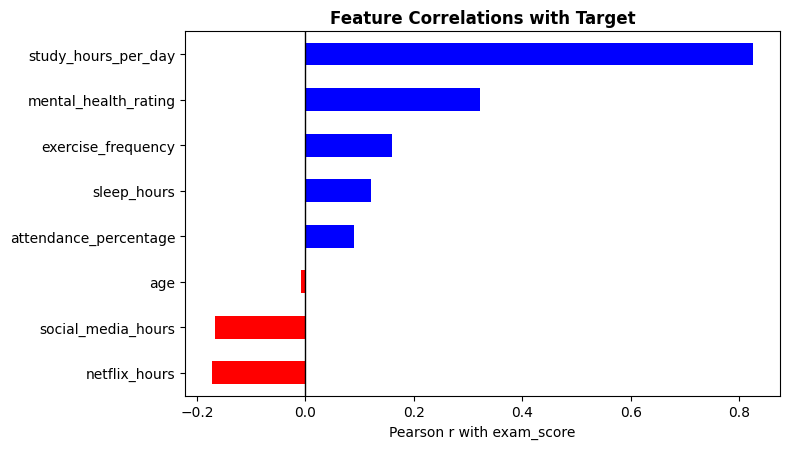

In [106]:
corr_with_target = (
    df.select_dtypes("number")
      .corr()[traget]
      .drop(traget)
      .sort_values()
)

palette = ["r" if v < 0 else "b" for v in corr_with_target]

fig, ax = plt.subplots(figsize=(8, len(corr_with_target) * 0.45 + 1))
corr_with_target.plot.barh(ax=ax, color=palette)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Pearson r with exam_score")
ax.set_title("Feature Correlations with Target", fontweight="bold")
plt.tight_layout()
plt.show()

## Heatmap

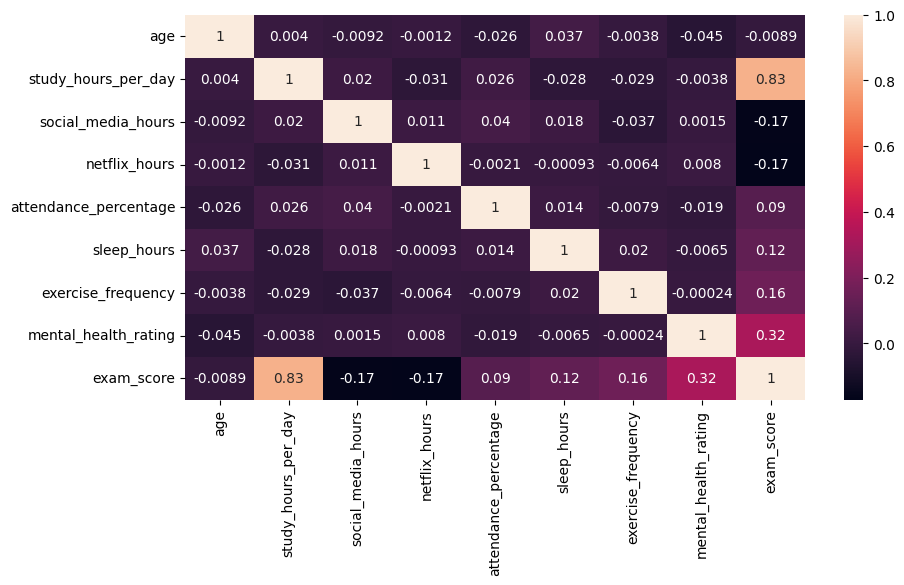

In [107]:
plt.figure(figsize=(10, 5))
corr=df.select_dtypes("number").corr()
sns.heatmap(corr,annot=True);

## Pre-processing

In [132]:
target="exam_score"
X=df.drop(columns=[target])
y=df[target]
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")

Train : 800 rows
Test  : 200 rows


## Models

In [109]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0,random_state=42),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000, random_state=42),
    "Decision Tree":DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42,n_jobs=-1),
    "Gradient Boosting":GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,max_depth=4, random_state=42),
    "XGBoost":XGBRegressor(n_estimators=200, learning_rate=0.05,max_depth=4, random_state=42,verbosity=0),
    "LightGBM":lgb.LGBMRegressor(n_estimators=200,learning_rate=0.05, max_depth=6,num_leaves=31, random_state=42,n_jobs=-1, verbose=-1)
}

## Model Comparison

In [110]:
results= []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.192343,5.150974,0.896531
1,Ridge Regression,4.192586,5.152090,0.896486
2,Lasso Regression,4.191766,5.150514,0.896549
3,Decision Tree,7.223862,9.172609,0.671891
4,Random Forest,4.984700,6.208197,0.849698
5,Gradient Boosting,4.722525,5.731622,0.871889
6,XGBoost,4.684926,5.646613,0.875661
7,LightGBM,4.774535,5.790383,0.869248


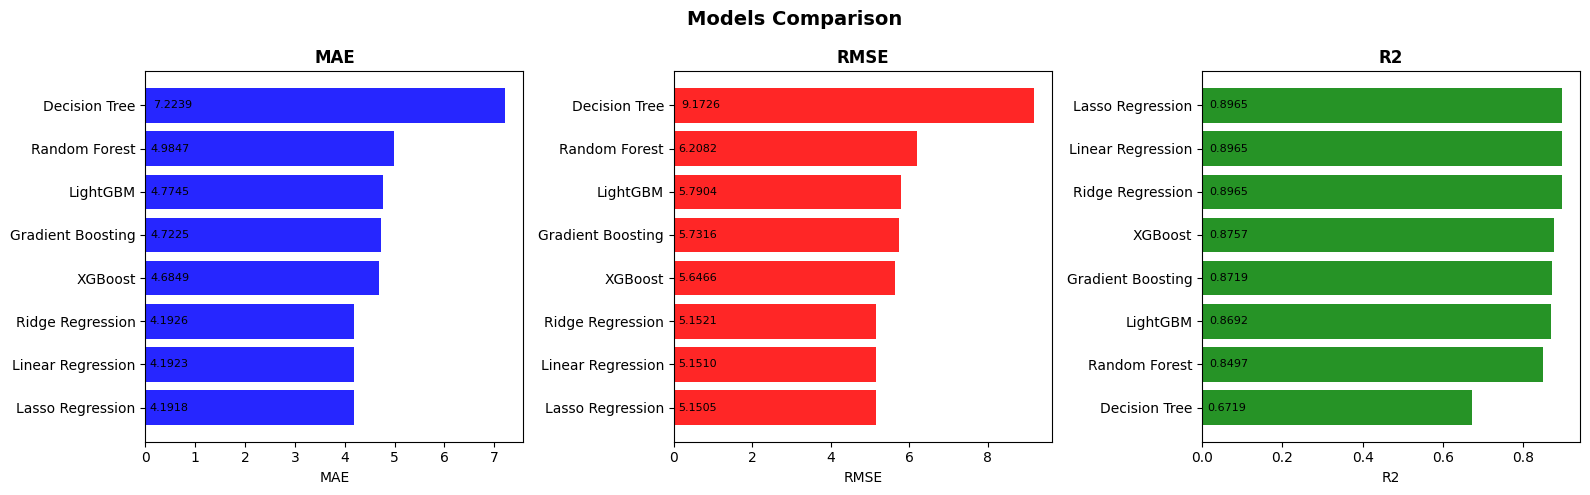

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["MAE", "RMSE", "R2"]
colors  = ["b", "r", "g"]

for ax, metric, color in zip(axes, metrics, colors):
    ordered = results_df.sort_values(metric, ascending=True)
    ax.barh(ordered["Model"], ordered[metric], color=color, alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight="bold")
    # Annotate bars
    for i, v in enumerate(ordered[metric]):
        ax.text(v * 0.02, i, f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Models Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [112]:
final_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model',  Lasso(alpha=0.01))
])

final_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [113]:
final_preds = final_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, final_preds))
print("RMSE:",np.sqrt(mean_squared_error(y_test, final_preds)))
print("R²:", r2_score(y_test, final_preds))

MAE: 4.186662102892267
RMSE: 5.146546413113241
R²: 0.89670852334819


In [114]:
def make_predictions(age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,
        diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation):
    data={
        "age":age,
        "gender":gender,
        "study_hours_per_day":study_hours_per_day,
        "social_media_hours":social_media_hours,
        "netflix_hours":netflix_hours,
        "part_time_job":part_time_job,
        "attendance_percentage":attendance_percentage,
        "sleep_hours":sleep_hours,
        "diet_quality":diet_quality,
        "exercise_frequency":exercise_frequency,
        "parental_education_level":parental_education_level,
        "internet_quality":internet_quality,
        "mental_health_rating":mental_health_rating,
        "extracurricular_participation":extracurricular_participation
    }
    df=pd.DataFrame(data,index=[0])
    prediction =final_model.predict(df).round(2)[0]
    return f"exam_score: {prediction}"

In [115]:
interact(
    make_predictions,
    age=IntSlider(
        min=X_train["age"].min(),
        max=X_train["age"].max(),
        value=X_train["age"].mean()
    ),
    gender=Dropdown(options=sorted(X_train["gender"].unique())),
    study_hours_per_day=FloatSlider(
        min=X_train["study_hours_per_day"].min(),
        max=X_train["study_hours_per_day"].max(),
        value=X_train["study_hours_per_day"].mean()
    ),
    social_media_hours=FloatSlider(
        min=X_train["social_media_hours"].min(),
        max=X_train["social_media_hours"].max(),
        value=X_train["social_media_hours"].mean()
    ),
    netflix_hours=FloatSlider(
        min=X_train["netflix_hours"].min(),
        max=X_train["netflix_hours"].max(),
        value=X_train["netflix_hours"].mean()
    ),
    part_time_job=Dropdown(options=sorted(X_train["part_time_job"].unique())),
    attendance_percentage=FloatSlider(
        min=X_train["attendance_percentage"].min(),
        max=X_train["attendance_percentage"].max(),
        value=X_train["attendance_percentage"].mean()
    ),
    sleep_hours=FloatSlider(
        min=X_train["sleep_hours"].min(),
        max=X_train["sleep_hours"].max(),
        value=X_train["sleep_hours"].mean()
    ),
    diet_quality=Dropdown(options=sorted(X_train["diet_quality"].unique())),
    exercise_frequency=IntSlider(
        min=X_train["exercise_frequency"].min(),
        max=X_train["exercise_frequency"].max(),
        value=X_train["exercise_frequency"].mean()
    ),
    parental_education_level=Dropdown(options=sorted(X_train["parental_education_level"].dropna().unique())),
    internet_quality=Dropdown(options=sorted(X_train["internet_quality"].unique())),
    mental_health_rating=IntSlider(
        min=X_train["mental_health_rating"].min(),
        max=X_train["mental_health_rating"].max(),
        value=X_train["mental_health_rating"].mean()
    ),
    extracurricular_participation=Dropdown(options=sorted(X_train["extracurricular_participation"].unique()))
)

interactive(children=(IntSlider(value=20, description='age', max=24, min=17), Dropdown(description='gender', o…

<function __main__.make_predictions(age, gender, study_hours_per_day, social_media_hours, netflix_hours, part_time_job, attendance_percentage, sleep_hours, diet_quality, exercise_frequency, parental_education_level, internet_quality, mental_health_rating, extracurricular_participation)>